<a href="https://colab.research.google.com/github/goldedan7/robot-dynamics/blob/main/P2_robot_arm/P2_RobotArm_Kinematics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
print("libraries ready")

libraries ready


In [3]:
L1 = 1.0 # length of link 1(m) - shoulder to elbow
L2 = 0.8 # length of link 2(m) - elbow to end-effector

print(f"Link 1: {L1}m, Link 2: {L2}m")


Link 1: 1.0m, Link 2: 0.8m


In [4]:
def forward_kinematics(theta1, theta2):
    """
    Compute the position of the elbow and end-effector
    given two joint angles.

    theta1 : angle of link 1 from the horizontal (rad)
    theta2 : angle of link 2 relative to link 1 (rad)

    Returns (elbow_x, elbow_y, end_x, end_y)
    """
    # Elbow position (end of link 1)
    elbow_x = L1 * np.cos(theta1)
    elbow_y = L1 * np.sin(theta1)

    # End-effector position (end of link 2)
    end_x = elbow_x + L2 * np.cos(theta1 + theta2)
    end_y = elbow_y + L2 * np.sin(theta1 + theta2)

    return elbow_x, elbow_y, end_x, end_y


# Quick check: both joints at 0 degrees → arm points straight along x-axis
ex, ey, fx, fy = forward_kinematics(0, 0)
print(f"Elbow: ({ex:.2f}, {ey:.2f})")
print(f"End-effector: ({fx:.2f}, {fy:.2f})")

Elbow: (1.00, 0.00)
End-effector: (1.80, 0.00)


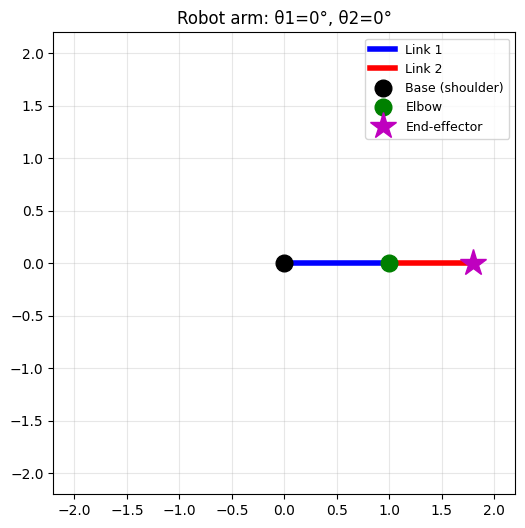

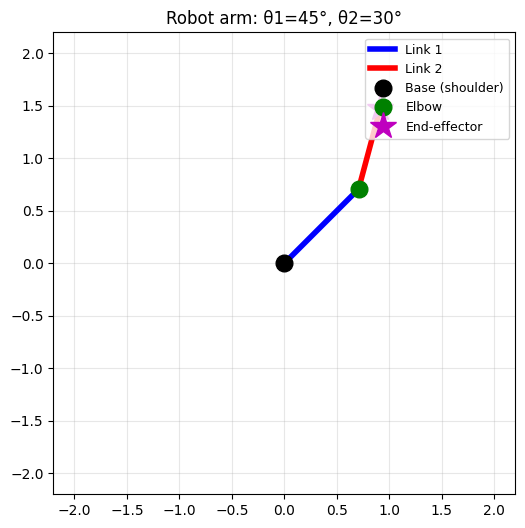

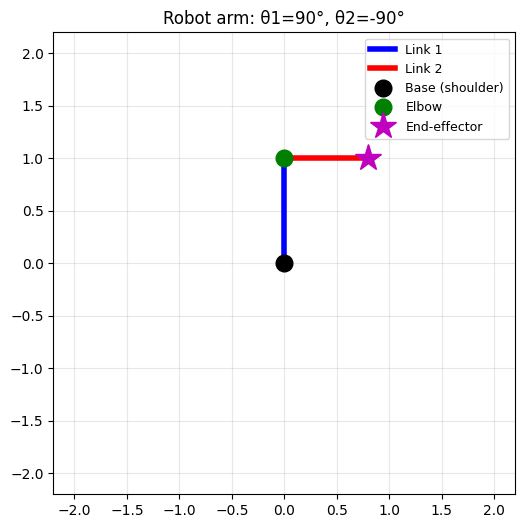

In [5]:
def plot_arm(theta1, theta2):
    """
    Draw the robot arm for given joint angles.
    """
    ex, ey, fx, fy = forward_kinematics(theta1, theta2)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Base (origin) → elbow
    ax.plot([0, ex], [0, ey], 'b-', linewidth=4, label='Link 1')
    # Elbow → end-effector
    ax.plot([ex, fx], [ey, fy], 'r-', linewidth=4, label='Link 2')

    # Joints as dots
    ax.plot(0, 0, 'ko', markersize=12, label='Base (shoulder)')
    ax.plot(ex, ey, 'go', markersize=12, label='Elbow')
    ax.plot(fx, fy, 'm*', markersize=20, label='End-effector')

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')   # keep x and y scales the same, or the arm looks distorted
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title(f'Robot arm: θ1={np.degrees(theta1):.0f}°, θ2={np.degrees(theta2):.0f}°')

    plt.show()


# Try a few configurations
plot_arm(np.radians(0), np.radians(0))     # straight arm
plot_arm(np.radians(45), np.radians(30))   # bent arm
plot_arm(np.radians(90), -np.radians(90))  # elbow folded back

<function matplotlib.pyplot.show(close=None, block=None)>

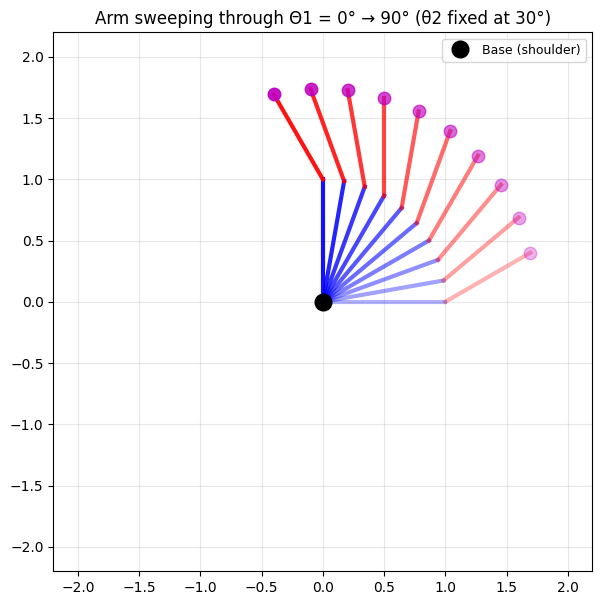

In [6]:
#Sweep theta1 from 0 to 90 degrees while theta2 stays fixed
theta1_values = np.linspace(0, np.radians(90), 10)
theta2_values = np.radians(30)

fig, ax = plt.subplots(figsize=(7, 7))
for i, th1 in enumerate(theta1_values):
    ex, ey, fx, fy = forward_kinematics(th1, theta2_values)

    # Fade older positions, highlight the latest one
    alpha = 0.3 + 0.7 * (i / (len(theta1_values - 1)))

    ax.plot([0, ex], [0, ey], 'b-', linewidth=3, alpha=alpha)
    ax.plot([ex, fx], [ey, fy], 'r-', linewidth=3, alpha=alpha)
    ax.plot(fx,fy, 'mo', markersize=9, alpha=alpha)

ax.plot(0, 0, 'ko', markersize=12, label='Base (shoulder)')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title('Arm sweeping through Θ1 = 0° → 90° (θ2 fixed at 30°)')
ax.legend(loc='upper right', fontsize=9)
plt.show



In [8]:
def distance_to_target(x, y):
  """
  straight-line distance from the shoulder (origin) tp the target point.
  This is tjust the Pythagorean theorem: distace = sqrt(x^2 + y^2)
  """
  return np.sqrt(x**2 + y**2)

#Test: how far is the point (1.5, 0.5)?
d = distance_to_target(1.5, 0.5)
print(f"Distance to target: {d:.2f} m")
print(f"Arm's maximum reach: {L1 + L2:.2f} m")


Distance to target: 1.58 m
Arm's maximum reach: 1.80 m


In [15]:
def inverse_kinematics(x, y):
    """
    Given a target end-effector position (x, y), compute the
    joint angles (theta1, theta2) needed to reach it.

    Uses the law of cosines on the triangle formed by:
      shoulder (0,0) -- elbow -- target (x,y)
    """
    d = distance_to_target(x, y)

    # Safety check: is the target within reach?
    if d > (L1 + L2):
        print("Target is out of reach!")
        return None, None

    # ── Elbow angle (theta2) ──────────────────────────
    # Law of cosines rearranged to solve for the angle:
    #   cos(theta2) = (d^2 - L1^2 - L2^2) / (2 * L1 * L2)
    cos_theta2 = (d**2 - L1**2 - L2**2) / (2 * L1 * L2)
    theta2 = np.arccos(cos_theta2)

    # ── Shoulder angle (theta1) ───────────────────────
    # Part A: angle pointing straight at the target
    angle_to_target = np.arctan2(y, x)

    # Part B: correction angle inside the triangle (offset caused
    # by the elbow bending instead of the arm being straight)
    cos_alpha = (L1**2 + d**2 - L2**2) / (2 * L1 * d)
    alpha = np.arccos(cos_alpha)

    theta1 = angle_to_target - alpha

    return theta1, theta2


# Test: reach for the point (1.5, 0.5)
theta1_sol, theta2_sol = inverse_kinematics(1.5, 0.5)
print(f"theta1 = {np.degrees(theta1_sol):.1f} deg")
print(f"theta2 = {np.degrees(theta2_sol):.1f} deg")

theta1 = -6.8 deg
theta2 = 57.5 deg


In [17]:
# Feed the IK solution back into forward kinematics
target_x, target_y = 1.5, 0.5   #target postion

theta1_sol, theta2_sol = inverse_kinematics(target_x, target_y)
ex, ey, fx, fy = forward_kinematics(theta1_sol, theta2_sol)

print(f"Target we asked for:     ({target_x:.2f}, {target_y:.2f})")
print(f"End-effector we got:     ({fx:.2f}, {fy:.2f})")
print(f"Match: {np.isclose(fx, target_x) and np.isclose(fy, target_y)}")

Target we asked for:     (1.50, 0.50)
End-effector we got:     (1.50, 0.50)
Match: True


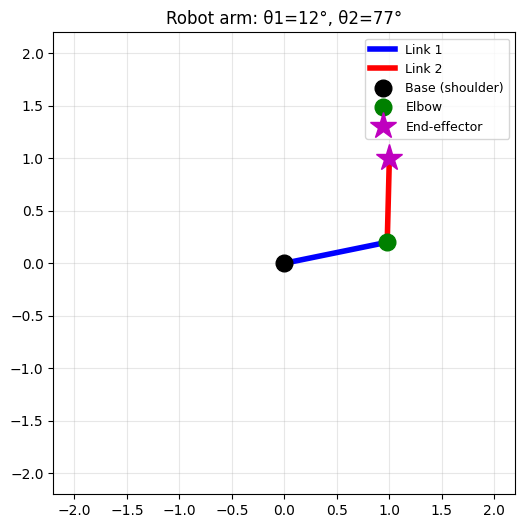

In [18]:
# Solve IK for a target, then draw the resulting arm pose
target_x, target_y = 1.0, 1.0

theta1_sol, theta2_sol = inverse_kinematics(target_x, target_y)

plot_arm(theta1_sol, theta2_sol) #using the same function in cell 4

In [19]:
# Try an unreachable target
theta1_bad, theta2_bad = inverse_kinematics(3.0, 3.0)

Target is out of reach!
